In [2]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"



In [6]:
defaultConfig = {"Budget": 3, "Theories": [["Hal", "Utility", 0], ["Carla", "Utility", 0]], "Considerations": [["Hal", "Hal"], ["Carla", "Carla"]]}
configs = []
for i in range(3,12):
    c = deepcopy(defaultConfig)
    c["Name"] = f"Horizon_{i}"
    c["Horizon"] = i
    configs.append(c)
    
Config_repetitions = 1
Environment_repetitions = 15

In [7]:
er = ExperimentRunner("LostInsulin", configs,MoralPlanner_Location="/../")
er.buildEnvironments(configRepetitions=1)
er.run(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)
er.saveResults()

Written LostInsulin MMMDP with 167 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-29_15:54:57/mdps/Horizon_3_con0.json

Written LostInsulin MMMDP with 321 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-29_15:54:57/mdps/Horizon_4_con0.json

Written LostInsulin MMMDP with 501 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /Users/user/Desktop/MyMoralPlanner/MoralPlanner/Notebooks/../Data/Experiments/LostInsulin/2026-06-29_15:54:57/mdps/Horizon_5_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}, {'Name': 'Ca

In [8]:
data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([json_data["Horizon"], env_rep, 
                            json_data["Duration_Heuristic"],
                            json_data["Duration_Plan"],
                            json_data["Duration_Sols"],
                            json_data["Duration_MEHR"],
                            json_data["Duration_Total"]])
time_cols = ["Heuristic", "Plan", "Solution Extraction", "MEHR", "Duration Total"]
cols = ["Horizon", "Env_rep"] + time_cols

df = pd.DataFrame(data, columns=cols)

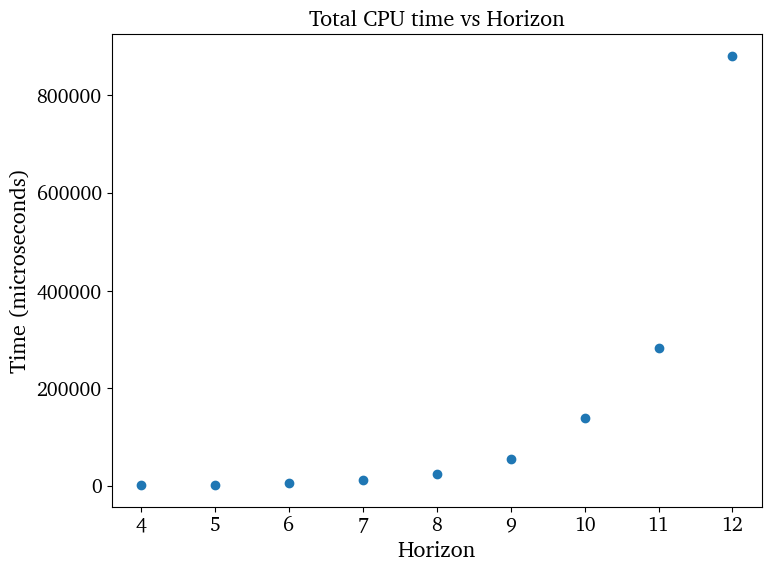

In [18]:
by_horizon = df.groupby('Horizon')[time_cols].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(by_horizon['Horizon'], by_horizon['Duration Total'])

#plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("Total CPU time vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("Time (microseconds)")
plt.xticks(ticks=np.arange(min(by_horizon['Horizon']), max(by_horizon['Horizon']) + 1, 1))


plt.tight_layout() 
plt.savefig(er.outputFolder + "timeVHorizon_LINEAR_SCALE.png")  # Save the plot
plt.show()  # Show the plot



In [24]:
averages_durations = df.groupby('Horizon')[time_cols].mean().reset_index()

plt.figure(figsize=(10, 6))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, column in enumerate(time_cols):
    current_color = colors[i % len(colors)]
    
    plt.scatter(average_durations['Horizon'], average_durations[column], color=current_color, label=column)

    # Calculate best fit line
    x = average_durations['Horizon']
    y = average_durations[column]
    slope, intercept, r_value, _, _ = linregress(x, np.log10(y))  # Fit line in log scale
    best_fit_line = 10 ** (slope * x + intercept)  # Transform back to original scale
    
    # Plot the line of best fit using the exact same color
    plt.plot(x, best_fit_line, linestyle='--', color=current_color, alpha=0.8, label=f'{column} Best Fit (R={r_value:.2f})')

plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("Time Metrics vs Horizon (Logarithmic Scale)")
plt.xlabel("Horizon")
plt.ylabel("Time (microseconds, log scale)")
plt.xticks(ticks=np.arange(min(average_durations['Horizon']), max(average_durations['Horizon']) + 1, 1))

# Move legend outside to avoid cluttering the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout() 
plt.savefig(er.outputFolder + "timeVHorizon_LOG_SCALE.png")  # Save the plot
plt.show()  # Show the plot

NameError: name 'average_durations' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:

data = []
for c in configs:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c["Name"], 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([json_data["Horizon"], env_rep, 
                            len(json_data["Solutions"]),
                            json_data["Backups"],
                            json_data["Total_Attacks"],
                            json_data["Total_states"]])
            
props_cols = ["Total Solutions", "Total Backups", "Total Attacks", "Total States"]
cols = ["Horizon", "Env_rep"] + props_cols
df = pd.DataFrame(data, columns=cols)

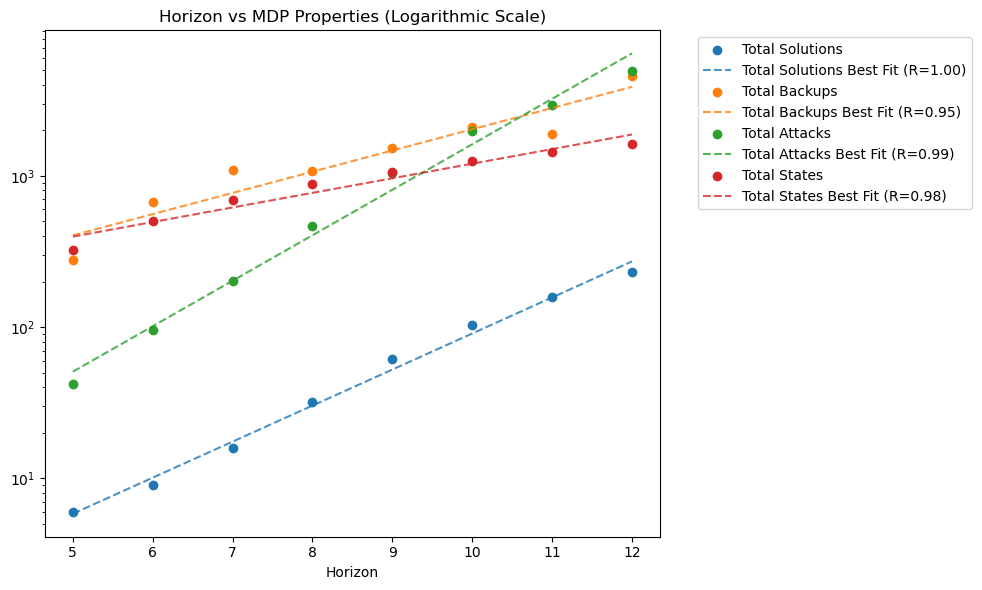

In [15]:
averages_props = df.groupby('Horizon')[props_cols].mean().reset_index()

plt.figure(figsize=(10, 6))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, column in enumerate(props_cols):
    current_color = colors[i % len(colors)]
    
    plt.scatter(average_durations['Horizon'], averages_props[column], color=current_color, label=column)

    # Calculate best fit line
    x = averages_props['Horizon']
    y = averages_props[column]
    slope, intercept, r_value, _, _ = linregress(x, np.log10(y))  # Fit line in log scale
    best_fit_line = 10 ** (slope * x + intercept)  # Transform back to original scale    
    plt.plot(x, best_fit_line, linestyle='--', color=current_color, alpha=0.8, label=f'{column} Best Fit (R={r_value:.2f})')

plt.yscale('log')  # Set the y-axis to logarithmic scale
plt.title("Horizon vs MDP Properties (Logarithmic Scale)")
plt.xlabel("Horizon")
plt.xticks(ticks=np.arange(min(averages_props['Horizon']), max(averages_props['Horizon']) + 1, 1))

# Optional: move legend outside if it gets too cluttered with double labels
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout() # Ensures the legend isn't cut off if moved outside
plt.savefig(er.outputFolder + "propsVHorizon_LOG_SCALE.png")  # Save the plot
plt.show()  # Show the plot

In [20]:
cols = ["Config_name", 'Hal_Utility', 'Carla_Utility', "Min_non_accept", "Num_of_min_non_accept", "Num_of_sols", "Total_time"]
df = pd.DataFrame(er.data, columns=["Horizon", "Env_rep", 'Hal', 'Carla'])

df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df.head(100)



,Horizon,Env_rep,Hal,Carla
0,5,0,-68.9674,0
1,5,1,-68.9674,0
2,5,2,-68.9674,0
3,5,3,-68.9674,0
4,5,4,-68.9674,0
...,...,...,...,...
95,11,5,-49.2727,-15.4549
96,11,6,-49.2727,-15.4549
97,11,7,-49.2727,-15.4549
98,11,8,-49.2727,-15.4549


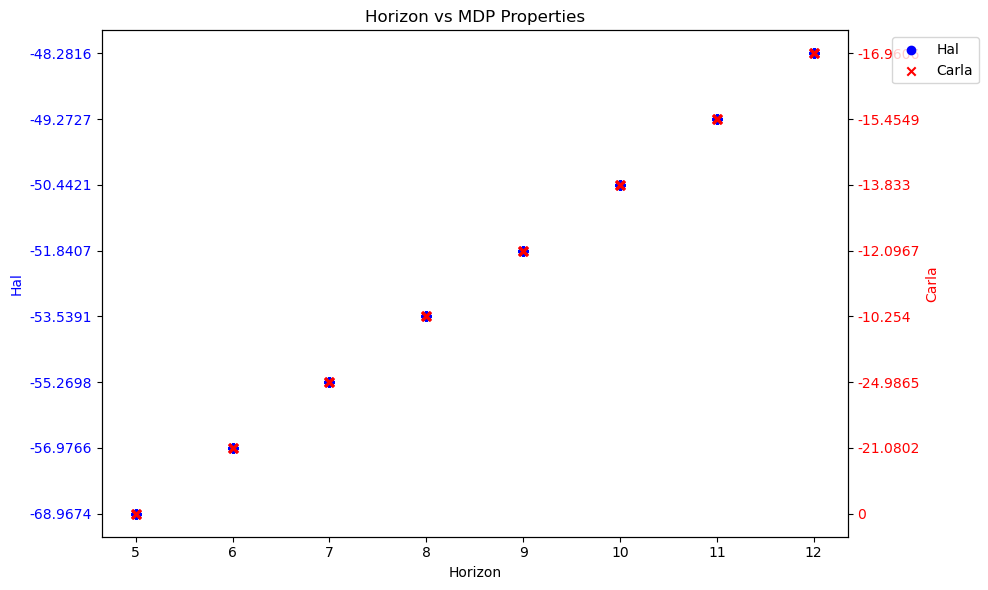

In [29]:
# Create the figure and the primary axis (for Hal)
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left Y-Axis (Hal) ---
color_hal = 'blue'
ax1.set_xlabel('Horizon')
ax1.set_ylabel('Hal', color=color_hal)
scatter_hal = ax1.scatter(df['Horizon'], df['Hal'], color=color_hal, label='Hal')
ax1.tick_params(axis='y', labelcolor=color_hal)

# Set x-ticks using the primary axis
ax1.set_xticks(np.arange(min(averages_props['Horizon']), max(averages_props['Horizon']) + 1, 1))

# --- Right Y-Axis (Carla) ---
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color_carla = 'red'
ax2.set_ylabel('Carla', color=color_carla)
scatter_carla = ax2.scatter(df['Horizon'], df['Carla'], color=color_carla, label='Carla', marker='x')
ax2.tick_params(axis='y', labelcolor=color_carla)

# --- Title and Legend ---
plt.title("Horizon vs MDP Properties")

# To get a single legend for both axes, we combine the handles and labels
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Formatting and Saving ---
fig.tight_layout() # Ensures the legend isn't cut off
plt.savefig(er.outputFolder + "HalCarla_V_Horizon.png")
plt.show()